In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from scipy.linalg import null_space
from scipy.linalg import solve as linsolve
from scipy.linalg import svd
from scipy.linalg import eig as eigenvalues
from utils import *
rc('text', usetex=True)
rc('font', family='sans-serif', serif=['Helvetica'], size=18)

## Quantum Absorption Refrigerator ##


In [ ]:
def H_refrigerator(Delta, Omega1, Omega2):
    """
    Three-level quantum absorption refrigerator Hamiltonian.
    Delta: energy gap ratio
    Omega1, Omega2: Rabi frequencies
    """
    H = np.array([
        [0, 0, Omega1],
        [0, Delta, Omega2],
        [Omega1, Omega2, 1.0]
    ], dtype=complex)
    return H


def nBE(E, T):
    """Bose-Einstein distribution"""
    if T == 0:
        return 0.0
    if np.abs(E) < 1e-12:
        return 0.0
    return 1.0 / (np.exp(E / T) - 1.0)


def diss_refrigerator(r):
    """
    Three-bath dissipator for quantum absorption refrigerator.
    Three reservoirs: cold (Tc), work/driving (Tw), hot (Th)
    """
    def func(Delta, Omega1, Omega2,
             gamma_c=0.1, gamma_w=0.1, gamma_h=0.1,
             Tc=0.5, Tw=1.0, Th=1.5):
        # Jump operators
        ColdDown = np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]], dtype=complex)
        ColdUp = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=complex)
        
        WorkDown = np.array([[0, 0, 0], [0, 0, 1], [0, 0, 0]], dtype=complex)
        WorkUp = np.array([[0, 0, 0], [0, 0, 0], [0, 1, 0]], dtype=complex)
        
        HotDown = np.array([[0, 0, 1], [0, 0, 0], [0, 0, 0]], dtype=complex)
        HotUp = np.array([[0, 0, 0], [0, 0, 0], [1, 0, 0]], dtype=complex)
        
        # Thermal occupation numbers
        nc = nBE(Delta, Tc) # |0><1|
        nw = nBE(1 - Delta, Tw) # |1><2|
        nh = nBE(Delta, Th) # |0><2|
        
        # Cold reservoir dissipator
        diss_cold = gamma_c * (nc + 1) * lindblad_dissipator(ColdDown, r) + \
                    gamma_c * nc * lindblad_dissipator(ColdUp, r)
        
        # Work/driving reservoir dissipator
        diss_work = gamma_w * (nw + 1) * lindblad_dissipator(WorkDown, r) + \
                    gamma_w * nw * lindblad_dissipator(WorkUp, r)
        
        # Hot reservoir dissipator
        diss_hot = gamma_h * (nh + 1) * lindblad_dissipator(HotDown, r) + \
                   gamma_h * nh * lindblad_dissipator(HotUp, r)
        
        return diss_cold + diss_work + diss_hot
    
    return func

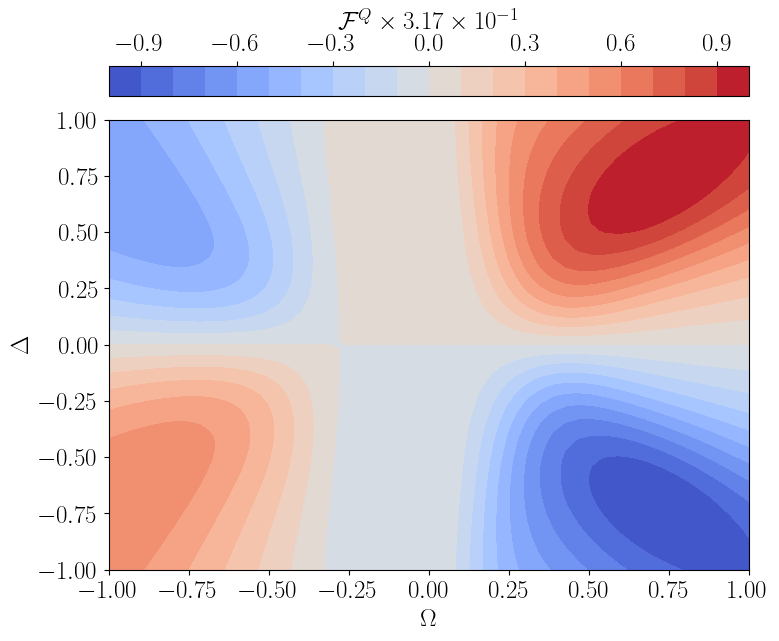

Computing Liouvillian Gap for 3x3 system...
Liouvillian gap between 2.38e-01 and 1.84e+01.


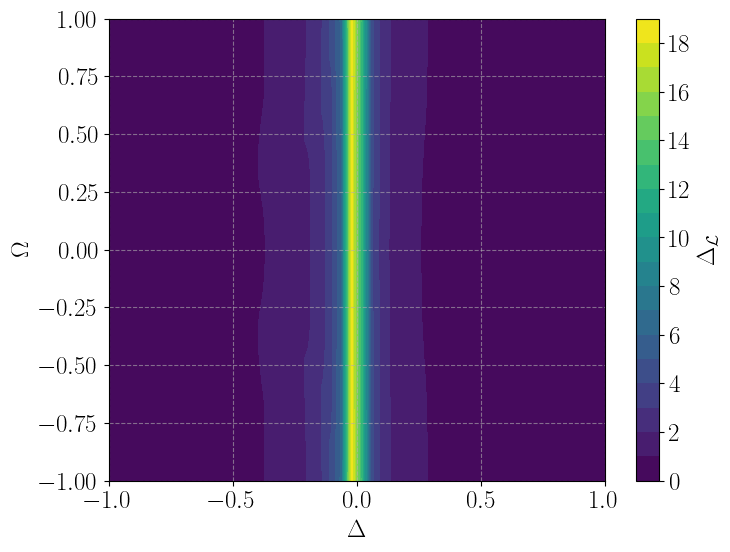

Starting cycle integration for d=3 system...
--- Results ---
Geometric Heat: 0.01092937714713678
Dissipated Heat: 0.04734291718274058
Net: 0.05827229432987736
Temperature change over the cycle: 0.05827229432987736 (arb. units)


In [ ]:
# Quantum Absorption Refrigerator Analysis
Delta_range = [r'$\Delta$', -1.0, 1.0]
Omega_range = [r'$\Omega$', -1.0, 1.0]

p1_grid_ref, p2_grid_ref, curvature_ref, max_val_ref = old_heat_curvature(
    H_refrigerator, H_refrigerator, diss_refrigerator,
    ranges=[Delta_range, Omega_range],
    points=50
)

# Plot Heat Curvature
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p2_grid_ref, p1_grid_ref, curvature_ref, levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val_ref:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\Omega$')
ax.set_ylabel(r'$\Delta$')
plt.savefig('refrigerator_curvature.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap for refrigerator
liouvillian_gap(
    H_refrigerator,
    diss_refrigerator,
    params=[r'$\Delta$', r'$\Omega$'],
    ranges=[Delta_range, Omega_range],
    points=50
)

# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_refrigerator,
    H_refrigerator,
    diss_refrigerator,
    p_min=[Delta_range[1], Omega_range[1]],
    p_max=[Delta_range[2], Omega_range[2]],
    tau=2 * np.pi,
    points=100
)

print("Temperature change over the cycle:", (q_geo_mtls + q_diss_mtls), "(arb. units)")